# Analyze DeepPeptide inference errors

Notebook for tables saved by `infer.py` into `runs/<run_name>/error_stats_infer/`.

Expected files per run:

- `test_protein_metrics.csv`
- `test_true_feature_metrics.csv`
- `test_pred_segment_metrics.csv`
- optional `homo_test_*` files

It also joins `data/uniprot_2026/processed_data/features_master.parquet` and `proteins_master.parquet` when available.

In [13]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RUNS_DIR = PROJECT_ROOT / 'runs'
DATA_DIR = PROJECT_ROOT / 'data' / 'uniprot_2026'
PROCESSED_DIR = DATA_DIR / 'processed_data'

STATS_DIR_NAME = 'error_stats_infer'  # change if you used another --output_suffix
SPLIT = 'test'                       # 'test' or 'homo_test'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RUNS_DIR:', RUNS_DIR)
print('DATA_DIR:', DATA_DIR)

PROJECT_ROOT: /home/oskar/work/DeepPeptide
RUNS_DIR: /home/oskar/work/DeepPeptide/runs
DATA_DIR: /home/oskar/work/DeepPeptide/data/uniprot_2026


## Load one or more runs

Set `RUN_NAMES` manually or leave it empty to load every run that has stats.

In [14]:
RUN_NAMES = []  # e.g. ['esm2_baseline', 'esm2_struct']

def find_run_stats_dirs(runs_dir=RUNS_DIR, stats_dir_name=STATS_DIR_NAME, run_names=None):
    run_names = set(run_names or [])
    out = []
    for run_dir in sorted(p for p in runs_dir.iterdir() if p.is_dir()):
        if run_names and run_dir.name not in run_names:
            continue
        stats_dir = run_dir / stats_dir_name
        if stats_dir.exists():
            out.append((run_dir.name, stats_dir))
    return out

run_stats_dirs = find_run_stats_dirs(run_names=RUN_NAMES)
print('Found stats dirs:', len(run_stats_dirs))
for name, path in run_stats_dirs[:20]:
    print(name, '->', path)

Found stats dirs: 2
train_run_esm2 -> /home/oskar/work/DeepPeptide/runs/train_run_esm2/error_stats_infer
train_run_prostt5 -> /home/oskar/work/DeepPeptide/runs/train_run_prostt5/error_stats_infer


In [15]:
def load_stats(split=SPLIT):
    protein_parts = []
    true_feature_parts = []
    pred_segment_parts = []
    summaries = []

    for run_name, stats_dir in run_stats_dirs:
        protein_path = stats_dir / f'{split}_protein_metrics.csv'
        true_path = stats_dir / f'{split}_true_feature_metrics.csv'
        pred_path = stats_dir / f'{split}_pred_segment_metrics.csv'
        summary_path = stats_dir / f'{split}_summary.json'

        if not protein_path.exists() or not true_path.exists() or not pred_path.exists():
            print('skip missing', run_name)
            continue

        p = pd.read_csv(protein_path)
        t = pd.read_csv(true_path)
        s = pd.read_csv(pred_path)
        p['run_name'] = run_name
        t['run_name'] = run_name
        s['run_name'] = run_name
        protein_parts.append(p)
        true_feature_parts.append(t)
        pred_segment_parts.append(s)

        if summary_path.exists():
            with summary_path.open() as f:
                summary = json.load(f)
            summary['run_name'] = run_name
            summaries.append(summary)

    protein_df = pd.concat(protein_parts, ignore_index=True) if protein_parts else pd.DataFrame()
    true_feature_df = pd.concat(true_feature_parts, ignore_index=True) if true_feature_parts else pd.DataFrame()
    pred_segment_df = pd.concat(pred_segment_parts, ignore_index=True) if pred_segment_parts else pd.DataFrame()
    summary_df = pd.DataFrame(summaries)
    return protein_df, true_feature_df, pred_segment_df, summary_df

protein_df, true_feature_df, pred_segment_df, summary_df = load_stats()
print('protein rows:', len(protein_df))
print('true feature rows:', len(true_feature_df))
print('pred segment rows:', len(pred_segment_df))
summary_df.head()

protein rows: 3041
true feature rows: 5217
pred segment rows: 4330


,n_proteins,n_true_features,n_pred_segments,iou_threshold,true_feature_error_type_counts,true_feature_label_counts,pred_segment_error_type_counts,pred_segment_label_counts,mean_macro_f1_no_other,run_name
0,1503,2591,2358,0.5,"{'tp_iou50_boundary_shift': 930, 'tp_exact': 8...","{'PROPEP': 1386, 'PEPTIDE': 1205}","{'tp_exact': 898, 'tp_iou50_boundary_shift': 8...","{'PROPEP': 1306, 'PEPTIDE': 1052}",0.893055,train_run_esm2
1,1538,2626,1972,0.5,"{'tp_iou50_boundary_shift': 946, 'missed_no_ov...","{'PROPEP': 1421, 'PEPTIDE': 1205}","{'tp_iou50_boundary_shift': 915, 'tp_exact': 5...","{'PROPEP': 1062, 'PEPTIDE': 910}",0.859045,train_run_prostt5


## Optional join with UniProt master tables

In [16]:
features_master_path = PROCESSED_DIR / 'features_master.parquet'
proteins_master_path = PROCESSED_DIR / 'proteins_master.parquet'

features_master = pd.read_parquet(features_master_path) if features_master_path.exists() else pd.DataFrame()
proteins_master = pd.read_parquet(proteins_master_path) if proteins_master_path.exists() else pd.DataFrame()

print('features_master:', features_master.shape)
print('proteins_master:', proteins_master.shape)

if not features_master.empty and not true_feature_df.empty:
    fm = features_master.copy()
    fm = fm[fm['label'].isin(['PEPTIDE', 'PROPEP'])].copy()

    if 'protein_id' in fm.columns and 'accession' in fm.columns:
        fm = fm.drop(columns=['protein_id'])
    if 'accession' in fm.columns:
        fm = fm.rename(columns={'accession': 'protein_id'})

    fm = fm.rename(columns={
        'label': 'true_label',
        'start': 'true_start',
        'end': 'true_end',
        'length': 'feature_master_length',
        'description': 'feature_description',
    })

    meta_cols = [c for c in [
        'protein_id', 'true_label', 'true_start', 'true_end',
        'feature_description', 'evidence_codes', 'evidence_sources', 'pubmed_ids',
        'raw_feature_type', 'feature_master_length', 'drop_reason',
        'deeppeptide_extra_drop_reason', 'is_valid_for_training',
        'is_valid_for_training_deeppeptide'
    ] if c in fm.columns]

    fm_meta = fm[meta_cols].copy()
    fm_meta = fm_meta.loc[:, ~fm_meta.columns.duplicated()]
    fm_meta = fm_meta.drop_duplicates(['protein_id', 'true_label', 'true_start', 'true_end'])

    true_feature_df = true_feature_df.merge(
        fm_meta,
        on=['protein_id', 'true_label', 'true_start', 'true_end'],
        how='left'
    )

if not proteins_master.empty and not protein_df.empty:
    pm = proteins_master.copy()

    if 'protein_id' in pm.columns and 'accession' in pm.columns:
        pm = pm.drop(columns=['protein_id'])
    if 'accession' in pm.columns:
        pm = pm.rename(columns={'accession': 'protein_id'})

    pm = pm.loc[:, ~pm.columns.duplicated()]

    meta_cols = [c for c in [
        'protein_id', 'entry_name', 'protein_name', 'taxon_id',
        'lineage', 'gene_names', 'length'
    ] if c in pm.columns]

    pm_meta = pm[meta_cols].drop_duplicates('protein_id')

    protein_df = protein_df.merge(
        pm_meta,
        on='protein_id',
        how='left',
        suffixes=('', '_master')
    )

print(true_feature_df.shape, protein_df.shape)

features_master: (254566, 22)
proteins_master: (18091, 12)
(5217, 40) (3041, 31)


## Run-level overview

In [17]:
if not protein_df.empty:
    run_overview = protein_df.groupby('run_name').agg(
        n_proteins=('protein_id', 'nunique'),
        mean_macro_f1_no_other=('macro_f1_no_other', 'mean'),
        mean_peptide_residue_f1=('peptide_residue_f1', 'mean'),
        mean_propeptide_residue_f1=('propeptide_residue_f1', 'mean'),
        missed_peptides=('missed_peptide_segments_iou50', 'sum'),
        missed_propeptides=('missed_propeptide_segments_iou50', 'sum'),
        fp_peptides=('false_positive_peptide_segments_iou50', 'sum'),
        fp_propeptides=('false_positive_propeptide_segments_iou50', 'sum'),
    ).sort_values('mean_macro_f1_no_other')
    display(run_overview)

,n_proteins,mean_macro_f1_no_other,mean_peptide_residue_f1,mean_propeptide_residue_f1,missed_peptides,missed_propeptides,fp_peptides,fp_propeptides
run_name,,,,,,,,
train_run_prostt5,1538,0.859045,0.840706,0.889969,574,593,279,234
train_run_esm2,1503,0.893055,0.896038,0.909131,404,398,251,318


## Error types for true features

In [18]:
if not true_feature_df.empty:
    err = pd.crosstab(
        [true_feature_df['run_name'], true_feature_df['true_label']],
        true_feature_df['error_type'],
        normalize='index'
    )
    display(err)

    counts = pd.crosstab(
        [true_feature_df['run_name'], true_feature_df['true_label']],
        true_feature_df['error_type']
    )
    display(counts)

error_type                    missed_no_overlap  partial_overlap_same_label  \
run_name          true_label                                                  
train_run_esm2    PEPTIDE              0.183402                    0.079668   
                  PROPEP               0.188312                    0.039683   
train_run_prostt5 PEPTIDE              0.315353                    0.087137   
                  PROPEP               0.259676                    0.053483   

error_type                    tp_exact  tp_iou50_boundary_shift  \
run_name          true_label                                      
train_run_esm2    PEPTIDE     0.443154                 0.253112   
                  PROPEP      0.262626                 0.450938   
train_run_prostt5 PEPTIDE     0.230705                 0.317842   
                  PROPEP      0.187192                 0.396200   

error_type                    wrong_label_iou50  wrong_label_partial_overlap  
run_name          true_label                                                  
train_run_esm2    PEPTIDE              0.024896                     0.015768  
                  PROPEP               0.031746                     0.026696  
train_run_prostt5 PEPTIDE              0.024066                     0.024896  
                  PROPEP               0.061224                     0.042224

error_type                    missed_no_overlap  partial_overlap_same_label  \
run_name          true_label                                                  
train_run_esm2    PEPTIDE                   221                          96   
                  PROPEP                    261                          55   
train_run_prostt5 PEPTIDE                   380                         105   
                  PROPEP                    369                          76   

error_type                    tp_exact  tp_iou50_boundary_shift  \
run_name          true_label                                      
train_run_esm2    PEPTIDE          534                      305   
                  PROPEP           364                      625   
train_run_prostt5 PEPTIDE          278                      383   
                  PROPEP           266                      563   

error_type                    wrong_label_iou50  wrong_label_partial_overlap  
run_name          true_label                                                  
train_run_esm2    PEPTIDE                    30                           19  
                  PROPEP                     44                           37  
train_run_prostt5 PEPTIDE                    29                           30  
                  PROPEP                     87                           60

## Worst proteins

In [19]:
if not protein_df.empty:
    worst_cols = [
        'run_name', 'protein_id', 'organism', 'entry_name', 'protein_name',
        'sequence_length', 'macro_f1_no_other',
        'true_n_peptide_segments', 'true_n_propeptide_segments',
        'missed_peptide_segments_iou50', 'missed_propeptide_segments_iou50',
        'false_positive_peptide_segments_iou50', 'false_positive_propeptide_segments_iou50',
    ]
    worst_cols = [c for c in worst_cols if c in protein_df.columns]
    worst = protein_df.sort_values(['macro_f1_no_other', 'missed_peptide_segments_iou50', 'missed_propeptide_segments_iou50'], ascending=[True, False, False])
    display(worst[worst_cols].head(50))

,run_name,protein_id,organism,entry_name,protein_name,sequence_length,macro_f1_no_other,true_n_peptide_segments,true_n_propeptide_segments,missed_peptide_segments_iou50,missed_propeptide_segments_iou50,false_positive_peptide_segments_iou50,false_positive_propeptide_segments_iou50
724,train_run_esm2,P05060,Homo sapiens (Human),SCG1_HUMAN,Secretogranin-1,677,0.061728,1,0,1,0,6,0
788,train_run_esm2,Q0VGU4,Mus musculus (Mouse),VGF_MOUSE,Neurosecretory protein VGF,617,0.080808,3,0,3,0,3,0
2085,train_run_prostt5,P0DME9,Heterometrus petersii (Asian forest scorpion),NDB4W_HETPE,Peptide Hp1412,68,0.085106,1,1,1,1,1,0
2198,train_run_prostt5,A0A0C4G489,Heterometrus spinifer (Asia giant forest scorp...,NDB2_HETSP,Heterin-1,83,0.093750,0,1,0,1,1,1
749,train_run_esm2,O35314,Rattus norvegicus (Rat),SCG1_RAT,Secretogranin-1,675,0.102326,1,0,0,0,8,0
2033,train_run_prostt5,C0HKS5,Agrotis ipsilon (Black cutworm moth),IRP4_AGRIP,Insulin-related peptide 4,88,0.138889,1,2,1,2,2,1
2533,train_run_prostt5,L0GBQ6,Urodacus yaschenkoi (Inland robust scorpion),NDB2_UROYA,Antimicrobial peptide Con22,81,0.146341,0,1,0,1,1,1
1787,train_run_prostt5,P68991,Chimaera monstrosa (Rabbit fish),INS_CHIMO,Insulin,59,0.156250,2,0,2,0,1,0
2871,train_run_prostt5,P68992,Hydrolagus colliei (Spotted ratfish) (Chimaera...,INS_HYDCO,Insulin,59,0.156250,2,0,2,0,1,0
904,train_run_esm2,P86435,Bos taurus (Bovine),VGF_BOVIN,Neurosecretory protein VGF,618,0.158590,3,0,2,0,3,0


## Stable bad features across runs

This is the main table for “which regions are consistently bad across pipelines”. A feature is considered failed when it is not `tp_exact` or `tp_iou50_boundary_shift`.

In [20]:
if not true_feature_df.empty:
    good_types = {'tp_exact', 'tp_iou50_boundary_shift'}
    tf = true_feature_df.copy()
    tf['is_failed'] = ~tf['error_type'].isin(good_types)

    group_cols = ['protein_id', 'true_label', 'true_start', 'true_end']
    stable = tf.groupby(group_cols).agg(
        n_runs=('run_name', 'nunique'),
        fail_rate=('is_failed', 'mean'),
        mean_iou=('best_same_label_iou', 'mean'),
        mean_abs_start_error=('best_same_label_abs_start_error', 'mean'),
        mean_abs_end_error=('best_same_label_abs_end_error', 'mean'),
        true_length=('true_length', 'first'),
        organism=('organism', 'first'),
        true_sequence=('true_sequence', 'first'),
        most_common_error=('error_type', lambda s: s.value_counts().idxmax()),
    ).reset_index()

    # Add optional metadata if present.
    extra_cols = [c for c in ['feature_description', 'evidence_codes', 'evidence_sources', 'pubmed_ids'] if c in tf.columns]
    if extra_cols:
        meta = tf[group_cols + extra_cols].drop_duplicates(group_cols)
        stable = stable.merge(meta, on=group_cols, how='left')

    stable_bad = stable.sort_values(['fail_rate', 'mean_iou'], ascending=[False, True])
    display(stable_bad.head(100))

    OUT = PROJECT_ROOT / 'runs' / f'stable_bad_features_{SPLIT}.csv'
    stable_bad.to_csv(OUT, index=False)
    print('saved:', OUT)

,protein_id,true_label,true_start,true_end,n_runs,fail_rate,mean_iou,mean_abs_start_error,mean_abs_end_error,true_length,organism,true_sequence,most_common_error,feature_description,evidence_codes,evidence_sources,pubmed_ids
3,A0A096P2H4,PROPEP,23,28,2,1.0,0.0,NaN,NaN,6,Papio anubis (Olive baboon),AQLPQQ,missed_no_overlap,Removed in mature form,[ECO:0000250],[UniProtKB],[]
22,A0A0B5A7P2,PROPEP,25,29,2,1.0,0.0,NaN,NaN,5,Conus geographus (Geography cone) (Nubecula ge...,NQHTR,wrong_label_partial_overlap,,[ECO:0000250],[UniProtKB],[]
33,A0A0B5A8Q2,PROPEP,25,29,2,1.0,0.0,NaN,NaN,5,Conus geographus (Geography cone) (Nubecula ge...,NQHTR,wrong_label_partial_overlap,,[ECO:0000250],[UniProtKB],[]
40,A0A0B5ABD5,PROPEP,25,29,2,1.0,0.0,NaN,NaN,5,Conus tulipa (Fish-hunting cone snail) (Tulip ...,NQHTR,wrong_label_partial_overlap,,[ECO:0000250],[UniProtKB],[]
57,A0A0B5AC90,PROPEP,25,29,2,1.0,0.0,NaN,NaN,5,Conus tulipa (Fish-hunting cone snail) (Tulip ...,NQHTR,wrong_label_partial_overlap,,[ECO:0000250],[UniProtKB],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,D2Y267,PEPTIDE,75,113,2,1.0,0.0,NaN,NaN,39,Cyriopagopus hainanus (Chinese bird spider) (H...,CIGEGVPCDENDPRCCSGLVCLKPTLHGIWYKSYYCYKK,missed_no_overlap,U11-theraphotoxin-Hhn1a,[],[],[]
416,D2Y268,PEPTIDE,75,113,2,1.0,0.0,NaN,NaN,39,Cyriopagopus hainanus (Chinese bird spider) (H...,CIGEGVPCDENDPRCCSGLVCLKPTLHGIWYKSYYCYKK,missed_no_overlap,U11-theraphotoxin-Hhn1a,[],[],[]
417,D2Y269,PEPTIDE,75,113,2,1.0,0.0,NaN,NaN,39,Cyriopagopus hainanus (Chinese bird spider) (H...,CIGEGVPCDENDPRCCSGLVCLKPTLHGIWYKSYYCYKK,missed_no_overlap,U11-theraphotoxin-Hhn1a,[],[],[]
418,D2Y270,PEPTIDE,75,113,2,1.0,0.0,NaN,NaN,39,Cyriopagopus hainanus (Chinese bird spider) (H...,CIGEGVPCDENDPRCCSGLVCLKPTLHGIWYKSYYCYKK,missed_no_overlap,U11-theraphotoxin-Hhn1a,[],[],[]


saved: /home/oskar/work/DeepPeptide/runs/stable_bad_features_test.csv


## False positive predicted segments

In [21]:
if not pred_segment_df.empty:
    fp = pred_segment_df[~pred_segment_df['error_type'].isin(['tp_exact', 'tp_iou50_boundary_shift'])].copy()
    cols = [
        'run_name', 'protein_id', 'organism', 'pred_label', 'pred_start', 'pred_end', 'pred_length',
        'pred_sequence', 'error_type', 'best_same_label_iou', 'best_any_label', 'best_any_iou',
        'min_distance_to_true_any', 'min_distance_to_true_same_label'
    ]
    cols = [c for c in cols if c in fp.columns]
    display(fp.sort_values(['error_type', 'best_same_label_iou']).head(100)[cols])

    fp_summary = fp.groupby(['run_name', 'pred_label', 'error_type']).size().rename('n').reset_index()
    display(fp_summary)

,run_name,protein_id,organism,pred_label,pred_start,pred_end,pred_length,pred_sequence,error_type,best_same_label_iou,best_any_label,best_any_iou,min_distance_to_true_any,min_distance_to_true_same_label
4215,train_run_prostt5,O24006,Impatiens balsamina (Balsam),PEPTIDE,298,333,36,CQSAEEAAAFQAGEVTASLMLIMFKACPCMGPVPSV,partial_false_positive_same_label,0.018182,PROPEP,0.972222,0,0.0
3175,train_run_prostt5,Q9VU58,Drosophila melanogaster (Fruit fly),PEPTIDE,44,86,43,FIEKLKALDAKKVEGLFKDGLNTVQEGLQKLNETFLQAPAAST,partial_false_positive_same_label,0.019231,PROPEP,0.976744,0,0.0
503,train_run_esm2,Q0VBW8,Bos taurus (Bovine),PEPTIDE,65,105,41,FLFHYSRTQEPAHPVKTGFPPVHPLMRLAAKLADRRMKTFW,partial_false_positive_same_label,0.027778,PROPEP,0.878049,0,0.0
3172,train_run_prostt5,P0DME9,Heterometrus petersii (Asian forest scorpion),PEPTIDE,35,68,34,LCGKRGLSDLYDLDEMFDGEISQADIDFLKELMR,partial_false_positive_same_label,0.044444,PROPEP,0.852941,0,0.0
3333,train_run_prostt5,A0A0C4G489,Heterometrus spinifer (Asia giant forest scorp...,PROPEP,23,68,46,GVWDWLKKTAKNVWNSDIVKQLKGKAINAAKNYVAEKIGATPSVAG,partial_false_positive_same_label,0.049180,PROPEP,0.049180,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3031,train_run_prostt5,Q10589,Homo sapiens (Human),PROPEP,176,180,5,SALLQ,partial_false_positive_same_label,0.263158,PROPEP,0.263158,0,0.0
1625,train_run_esm2,E4VP50,Mesobuthus eupeus (Lesser Asian scorpion) (But...,PEPTIDE,21,69,49,LFKLATKIIPSLFQRKKERSVMNRDLENLFDPYQRNLEMDRLLKQLRNY,partial_false_positive_same_label,0.264151,PROPEP,0.653061,0,0.0
695,train_run_esm2,Q1MX22,Bombyx mori (Silk moth),PEPTIDE,114,143,30,SVDEENSGYQAETNTYPQRRHRARNHFIRL,partial_false_positive_same_label,0.266667,PROPEP,0.580645,0,0.0
2929,train_run_prostt5,Q1MX22,Bombyx mori (Silk moth),PEPTIDE,114,143,30,SVDEENSGYQAETNTYPQRRHRARNHFIRL,partial_false_positive_same_label,0.266667,PROPEP,0.580645,0,0.0


,run_name,pred_label,error_type,n
0,train_run_esm2,PEPTIDE,partial_false_positive_same_label,56
1,train_run_esm2,PEPTIDE,spurious_false_positive,143
2,train_run_esm2,PEPTIDE,wrong_label_false_positive_iou50,36
3,train_run_esm2,PEPTIDE,wrong_label_false_positive_partial,16
4,train_run_esm2,PROPEP,partial_false_positive_same_label,56
5,train_run_esm2,PROPEP,spurious_false_positive,203
6,train_run_esm2,PROPEP,wrong_label_false_positive_iou50,30
7,train_run_esm2,PROPEP,wrong_label_false_positive_partial,29
8,train_run_prostt5,PEPTIDE,partial_false_positive_same_label,76
9,train_run_prostt5,PEPTIDE,spurious_false_positive,127


## Error by true feature length

,run_name,true_label,length_bin,n,fail_rate,mean_iou
0,train_run_esm2,PEPTIDE,"(0, 5]",19,0.631579,0.385716
1,train_run_esm2,PEPTIDE,"(5, 8]",89,0.348315,0.687622
2,train_run_esm2,PEPTIDE,"(8, 12]",116,0.267241,0.718750
3,train_run_esm2,PEPTIDE,"(12, 20]",188,0.212766,0.769491
4,train_run_esm2,PEPTIDE,"(20, 35]",609,0.267652,0.711784
5,train_run_esm2,PEPTIDE,"(35, 50]",184,0.483696,0.459675
6,train_run_esm2,PROPEP,"(0, 5]",28,0.607143,0.354875
7,train_run_esm2,PROPEP,"(5, 8]",193,0.523316,0.407890
8,train_run_esm2,PROPEP,"(8, 12]",151,0.615894,0.350150
9,train_run_esm2,PROPEP,"(12, 20]",209,0.291866,0.651776


/tmp/ipykernel_443251/3253884485.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='length_bin', columns='run_name', values='fail_rate')


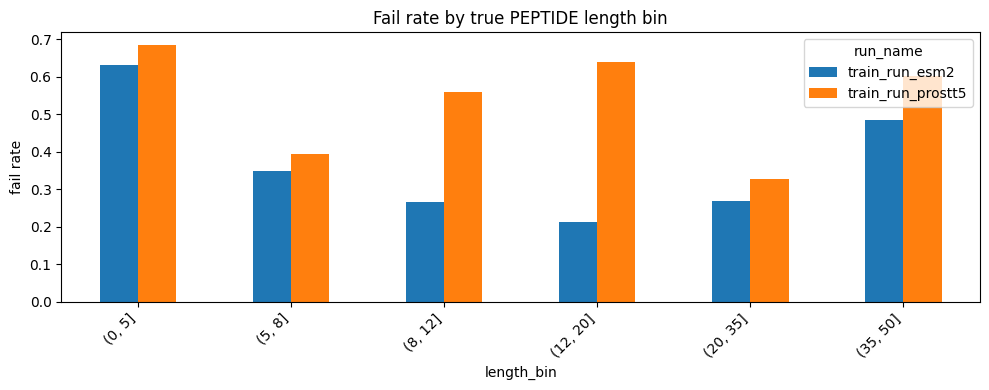

/tmp/ipykernel_443251/3253884485.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='length_bin', columns='run_name', values='fail_rate')


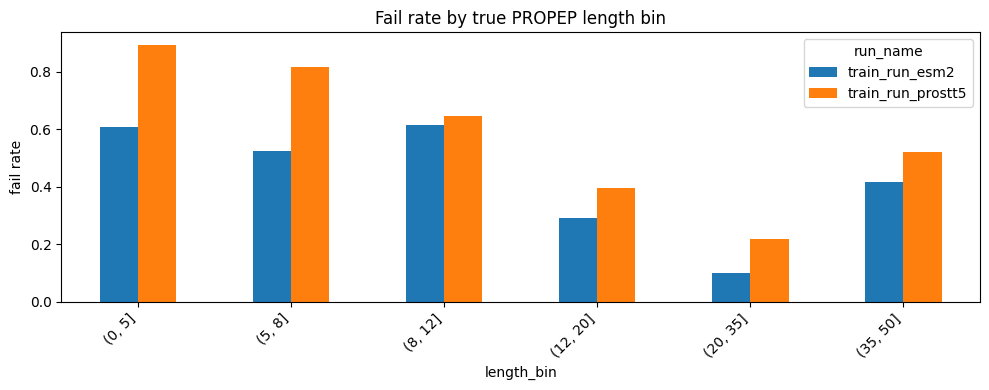

In [22]:
if not true_feature_df.empty:
    tf = true_feature_df.copy()
    good_types = {'tp_exact', 'tp_iou50_boundary_shift'}
    tf['is_failed'] = ~tf['error_type'].isin(good_types)
    tf['length_bin'] = pd.cut(tf['true_length'], bins=[0, 5, 8, 12, 20, 35, 50, 10_000], right=True)

    length_stats = tf.groupby(['run_name', 'true_label', 'length_bin'], observed=True).agg(
        n=('true_feature_id', 'count'),
        fail_rate=('is_failed', 'mean'),
        mean_iou=('best_same_label_iou', 'mean'),
    ).reset_index()
    display(length_stats)

    for label in ['PEPTIDE', 'PROPEP']:
        sub = length_stats[length_stats['true_label'] == label]
        if sub.empty:
            continue
        pivot = sub.pivot_table(index='length_bin', columns='run_name', values='fail_rate')
        ax = pivot.plot(kind='bar', figsize=(10, 4))
        ax.set_title(f'Fail rate by true {label} length bin')
        ax.set_ylabel('fail rate')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

## Error by organism / human subset

In [26]:
if not protein_df.empty:
    p = protein_df.copy()
    p['is_human'] = p['organism'].astype(str).str.contains('Homo sapiens', case=False, na=False)
    org_stats = p.groupby(['run_name', 'is_human']).agg(
        n_proteins=('protein_id', 'nunique'),
        mean_macro_f1_no_other=('macro_f1_no_other', 'mean'),
        mean_peptide_f1=('peptide_residue_f1', 'mean'),
        mean_propeptide_f1=('propeptide_residue_f1', 'mean'),
        missed_peptides=('missed_peptide_segments_iou50', 'sum'),
        missed_propeptides=('missed_propeptide_segments_iou50', 'sum'),
    ).reset_index()
    display(org_stats)

    top_orgs = p.groupby(['run_name', 'organism']).agg(
        n_proteins=('protein_id', 'nunique'),
        mean_macro_f1_no_other=('macro_f1_no_other', 'mean')
    ).reset_index().sort_values(['run_name', 'n_proteins'], ascending=[True, False])
    display(top_orgs.groupby('run_name').head(20))

,run_name,is_human,n_proteins,mean_macro_f1_no_other,mean_peptide_f1,mean_propeptide_f1,missed_peptides,missed_propeptides
0,train_run_esm2,False,1440,0.895024,0.898430,0.911374,384,382
1,train_run_esm2,True,63,0.847926,0.786991,0.857084,20,16
2,train_run_prostt5,False,1468,0.860029,0.841054,0.892229,551,573
3,train_run_prostt5,True,70,0.839651,0.822788,0.849526,23,20


,run_name,organism,n_proteins,mean_macro_f1_no_other
167,train_run_esm2,Cyriopagopus hainanus (Chinese bird spider) (H...,81,0.993421
33,train_run_esm2,Arabidopsis thaliana (Mouse-ear cress),69,0.945872
230,train_run_esm2,Homo sapiens (Human),63,0.847926
297,train_run_esm2,Mus musculus (Mouse),58,0.872107
398,train_run_esm2,Rattus norvegicus (Rat),47,0.850491
272,train_run_esm2,Lycosa singoriensis (Wolf spider) (Aranea sing...,40,0.907695
23,train_run_esm2,Anemonia viridis (Snakelocks anemone),34,0.874514
61,train_run_esm2,Bombyx mori (Silk moth),31,0.950925
62,train_run_esm2,Bos taurus (Bovine),30,0.777889
149,train_run_esm2,Conus textile (Cloth-of-gold cone),21,0.966773


## Save joined tables for manual inspection

In [24]:
OUT_DIR = RUNS_DIR / f'joined_error_analysis_{SPLIT}'
OUT_DIR.mkdir(exist_ok=True)

if not protein_df.empty:
    protein_df.to_csv(OUT_DIR / 'protein_metrics_joined.csv', index=False)
if not true_feature_df.empty:
    true_feature_df.to_csv(OUT_DIR / 'true_feature_metrics_joined.csv', index=False)
if not pred_segment_df.empty:
    pred_segment_df.to_csv(OUT_DIR / 'pred_segment_metrics_joined.csv', index=False)

print('saved to', OUT_DIR)

saved to /home/oskar/work/DeepPeptide/runs/joined_error_analysis_test
